# Capstone — Predicting Next-Month Content Decline for Editorial Triage

*FlyRank ML Internship capstone. This notebook mirrors the deployed research paper: same sections, same numbers.*

**Abstract.** Can a content team predict which already-visible pages will lose traffic next month, so limited review hours land where they matter? Using the FlyRank warehouse, I frame it as a ranking task — score each page by decline risk from history-only signals, rank, review the top. On a genuine forward window (features from Jan–Mar 2026, label from April 2026) the signal is **weak**: a grouped, unseen-client split gives AUC ≈ 0.56, and a learned model does **not** beat a transparent three-signal rule on the pages an editor would actually prioritize. The honest deliverable is that rule, gated on reach, with reason codes and human review — decision-support, not prediction.

## 1. Question

**The FlyRank content problem.** Editorial teams can only review a fraction of a site's pages each month. The costly mistake is spending that time on pages that were fine, while a page quietly loses the traffic it had. So: *which already-visible pages are most likely to decline next month, and in what order should a human review them?*

- **Unit of analysis:** one `(client, content item)` pair at a fixed **anchor date (2026-03-31)**.
- **Output:** a decline-risk score → a **ranked review queue** with plain-language reason codes.
- **Action:** an editor reviews the top of the queue first (refresh, expand, or leave alone).
- **Cost of a wrong call:** a false alarm wastes one review; a miss lets a valuable page decay unmitigated. Both are cheap per-page, which is why this is **triage support**, not automation.
- **Why data/ML at all:** the interactions between engagement, recency, and momentum are too noisy for a single hand-rule to rank thousands of pages — but, as the results show, they are also *weak*, and saying so honestly is part of the answer.

## 2. Data

**Release:** the gated FlyRank internship warehouse (`FlyRank/internship-warehouse`, build v20260703), read directly with DuckDB — never downloaded, no private data in the repo.

- **Table:** `fact_content_daily_performance` (daily GSC/GA4 grain), joined to `dim_content` and `dim_clients` for static attributes and panel start dates (context only).
- **Windows (no overlap):** features from the trailing 90 days (**Jan/Feb/Mar 2026**, as three 30-day blocks); label from the **30 days after the anchor (April 2026)**. June 2026 (`_sample`) stays sealed.
- **Population:** clients with full GSC history before the anchor, published & non-deleted pages, with a March baseline (`impr_prev > 0`).
- **Deliberately excluded (public-safe):** the April label window itself; any 90-day column that overlaps the label; `trend_pct`/`trend_direction` and the Health Score / product flags (label-derived or decision-derived); pseudonymous `content_hash_id`/`client_hash_id` (grouping only, never features).

In [1]:
import json
meta = json.load(open("../outputs/feature_metadata.json"))
for k in ["source","anchor","modeled_rows","clients","decline_base_rate",
          "feature_window","label_window","label_definition"]:
    print(f"{k:20s}: {meta[k]}")

source              : warehouse fact_content_daily_performance months 2026-01..2026-04
anchor              : 2026-03-31
modeled_rows        : 145030
clients             : 28
decline_base_rate   : 0.5438736813073157
feature_window      : trailing 90 days (Jan-Mar 2026)
label_window        : April 2026 (forward 30 days)
label_definition    : April 2026 impressions < 0.8 * March 2026 impressions


## 3. Methodology

- **Label (one sentence):** `future_decline = 1` if a pair's April 2026 impressions fall below **80% of its March 2026 impressions** (a ≥20% next-month drop).
- **Features (19, history-only):** log-scaled prior-window impressions/clicks/sessions and deepest-block impressions; historical CTR; a past→past momentum ratio; keyword search volume / competition / CPC; word & character counts; content age, days-since-last-update (future updates excluded), age tier; two `has_*` missingness flags; and three categoricals (content type, intent, competition level).
- **Baseline (the rule to beat):** three signals the audit confirmed — **thin CTR**, **not recently updated (≥31 days)**, **losing momentum** — each worth one point; ties broken by lowest CTR. Reason codes: `thin_ctr | stale_content | losing_momentum`.
- **Split:** **`GroupKFold(5)` by client**, out-of-fold — every page is scored by a model that never saw its client. Random splits are reported only to expose memorization.
- **Leakage checks:** a programmatic guard asserts no label-window / product-flag / identifier column enters the features; injecting a label-derived column sends AUC to ~1.0, confirming the harness works.

## 4. Results (vs baseline)

Read the table below with the base rate next to it. Two honest findings:

1. **Overall signal is weak** — logistic AUC ≈ 0.51, HGB ≈ 0.55 out-of-fold on unseen clients.
2. **The model does not beat the rule where it counts.** On editorially-relevant pages (`reach ≥ 100` impressions), the transparent rule's precision@50 is *as good as or better than* the learned models. Per "simplicity is a feature," the rule ships.

In [2]:
import pandas as pd, numpy as np
from sklearn.metrics import roc_auc_score

ms = pd.read_csv("../outputs/model_scores.csv").merge(
    pd.read_csv("../outputs/feature_vector.csv")[["content_id", "ctr_prev_30d"]], on="content_id")
y = ms.future_decline.to_numpy()
reach = ms.reach_impr.to_numpy()
BASE = y.mean()
base = ms.baseline_points.to_numpy() + (0.5 - ms.ctr_prev_30d.rank(pct=True).to_numpy()) * 1e-3

def pk(s, k, mask=None):
    idx = np.arange(len(y)) if mask is None else np.where(mask)[0]
    o = idx[np.argsort(-s[idx], kind="stable")]
    return y[o[:k]].mean()

m = reach >= 100
rows = [["rule baseline", "--", pk(base, 50), pk(base, 50, m)],
        ["logistic", roc_auc_score(y, ms.p_logit), pk(ms.p_logit.values, 50), pk(ms.p_logit.values, 50, m)],
        ["HGB", roc_auc_score(y, ms.p_hgb), pk(ms.p_hgb.values, 50), pk(ms.p_hgb.values, 50, m)]]
tbl = pd.DataFrame(rows, columns=["method", "AUC (grouped OOF)", "P@50 all", "P@50 reach>=100"])
for c in ["AUC (grouped OOF)", "P@50 all", "P@50 reach>=100"]:
    tbl[c] = tbl[c].apply(lambda v: f"{v:.3f}" if isinstance(v, float) else v)
print(f"base rate = {BASE:.3f}   |   reach>=100 base = {y[m].mean():.3f}\n")
print(tbl.to_string(index=False))

val = json.load(open("../outputs/summary.json"))["validation"]
print(f"\nmemorization check  ->  random-split AUC {val['random_split_auc']:.3f}  "
      f"vs  grouped-split AUC {val['grouped_split_auc']:.3f}")

base rate = 0.544   |   reach>=100 base = 0.538

       method AUC (grouped OOF) P@50 all P@50 reach>=100
rule baseline                --    0.560           0.660
     logistic             0.508    0.500           0.600
          HGB             0.548    0.460           0.460

memorization check  ->  random-split AUC 0.653  vs  grouped-split AUC 0.557


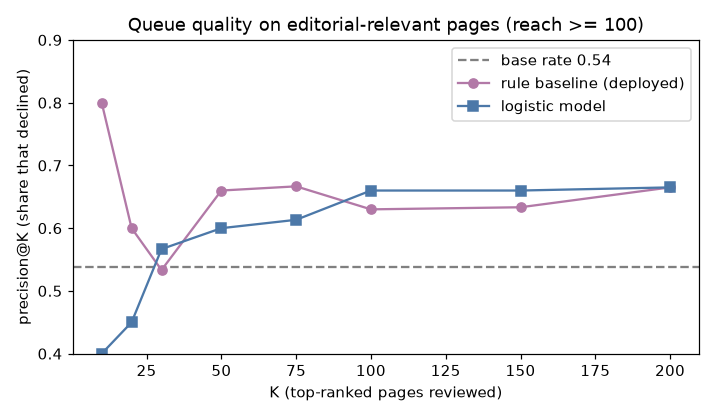

In [3]:
from IPython.display import Image
Image("../outputs/fig_precision_at_k.png")

## 5. Limitations

- **Weak signal, stated plainly.** Grouped-split AUC ≈ 0.56 — a little above chance. A high rank means "worth a look," never "this will drop."
- **Observational, one anchor.** Everything is measured on the 2026-03-31 slice for eligible clients; numbers are `directional` until reproduced on other anchors/clients. No intervention was run, so nothing here shows that *refreshing* a page *causes* retention.
- **Scope.** Out of scope: new pages, zero-impression pages, and pages below the `reach ≥ 100` gate.
- **Threshold artifact.** The ±20% label is denominator-sensitive for tiny pages — the reach gate is partly there to keep the queue on pages where the label is meaningful.

## 6. Ranked recommendations

Ship the **rule**, gated on reach, as a review queue. Each page carries reason codes so an editor trusts the "why." The top of the queue declines above the base rate — a real but modest lift.

- **Archetype → action:** `thin_ctr` → review title/snippet & intent match; `stale_content` → refresh facts/examples if the topic still has demand; `losing_momentum` → check for a seasonal dip before acting.
- **Confidence & limits:** `directional`; roughly half the very top are false alarms, and the cleanest signal is the **low-risk floor** (zero reason codes ⇒ ~0.33 decline) — the rule is better at "leave this alone" than "this will drop."
- **No-go:** never auto-edit/unpublish/redirect from a rank; no cross-client scoreboard; a human reviews every item.

In [4]:
q = pd.read_csv("../outputs/content_action_queue.csv")
print(f"review queue: {len(q):,} pages (reach>=100) | "
      f"top-50 observed decline {q.future_decline.head(50).mean():.3f} vs base {BASE:.3f}\n")
top = q.head(8).copy()
top["cid"] = top.content_id.str[-6:]
print(top[["rank","cid","reach","risk_points","reason_codes","confidence"]].to_string(index=False))

review queue: 85,410 pages (reach>=100) | top-50 observed decline 0.660 vs base 0.544

 rank    cid  reach  risk_points                  reason_codes confidence
    1 26c7db    136            2 stale_content|losing_momentum     higher
    2 2b9e9d    100            2 stale_content|losing_momentum     higher
    3 ffa87e    221            2 stale_content|losing_momentum     higher
    4 af9316    762            2 stale_content|losing_momentum     higher
    5 ce90e4    161            2 stale_content|losing_momentum     higher
    6 7b05d3    279            2 stale_content|losing_momentum     higher
    7 98c909   2270            2 stale_content|losing_momentum     higher
    8 4d8747    160            2 stale_content|losing_momentum     higher


## 7. Artifacts the paper embeds

The paper builds only on files this repo regenerates — the metrics JSONs (committed receipts) and the precision@K figure. The CSV queues stay out of git by design and rebuild on every run.

In [5]:
import os
for f in ["feature_vector.csv","baseline_action_score.csv","model_scores.csv",
          "content_action_queue.csv","fig_precision_at_k.png",
          "feature_metadata.json","baseline_metadata.json","model_results.json","summary.json"]:
    p = f"../outputs/{f}"
    tag = "committed" if (f.endswith(".json") or f.endswith(".png")) else "regenerated (gitignored)"
    print(f"  [{'ok' if os.path.exists(p) else '--'}] {f:<28} {tag}")

  [ok] feature_vector.csv           regenerated (gitignored)
  [ok] baseline_action_score.csv    regenerated (gitignored)
  [ok] model_scores.csv             regenerated (gitignored)
  [ok] content_action_queue.csv     regenerated (gitignored)
  [ok] fig_precision_at_k.png       committed
  [ok] feature_metadata.json        committed
  [ok] baseline_metadata.json       committed
  [ok] model_results.json           committed
  [ok] summary.json                 committed


## 8. Reproducibility

From a fresh clone (data access + `HF_TOKEN` in a local `.env` or Colab Secret):

```
pip install -r requirements.txt
python work/scripts/run_all.py       # 01 prepare -> 02 baseline -> 03 train -> 04 evaluate/export
```

or run the notebooks in order (`w03` → `w07`). Seeds are fixed (`SEED = 42`); the scripts reproduce the notebook numbers byte-for-byte. Environment: pandas 3.0, scikit-learn 1.9, duckdb, matplotlib.

## Demo outline (5 minutes) + shareable cuts

**5-minute demo**
1. **Question (45s)** — editors can't review every page; which already-visible pages decline next month, and in what order?
2. **Method (60s)** — warehouse panel; features from Jan–Mar, label from April (≥20% impressions drop); grouped-by-client split so it's tested on unseen clients.
3. **One chart (60s)** — precision@K on reach≥100 pages: the transparent rule tracks or beats the learned model, both only a little above the 0.54 base rate.
4. **One honest result (60s)** — the signal is weak (AUC ≈ 0.56) and the model doesn't beat a three-signal rule; the clean win is the low-risk floor (zero flags ⇒ ~0.33 decline).
5. **One recommendation (45s)** — ship the rule as a reason-coded, reach-gated review queue with a human in the loop; monitor base-rate drift and retrain per anchor.

---

**Social post (methodology)**

> Spent my FlyRank internship trying to predict which web pages lose traffic next month. Built the honest way: a real forward window (train on Jan–Mar, test on April), a *grouped-by-client* split so the model is judged on sites it never saw, and a leakage guard that screams if the label sneaks into the features. The punchline surprised me — a plain 3-signal rule matched a gradient-boosted model, and both barely beat the base rate. Sometimes the rigorous result is "the signal is weak," and saying so *is* the finding. #MachineLearning #SEO #DataScience

**Employer-facing summary (3 sentences)**

> I built a decision-support tool that ranks web pages by their risk of losing search traffic next month, on a ~145k-page panel from the FlyRank warehouse, validated on held-out clients with strict leakage checks. I found the honest result that history-only signals are weakly predictive (grouped AUC ≈ 0.56) and that a transparent, reason-coded rule matched a learned model on the pages that matter — so I shipped the rule, gated on reach, with human review. The work shows I can frame a problem, validate it without fooling myself, and choose the simplest defensible tool over chasing a metric.

## Self-check

- [x] Every section mirrors the deployed paper — question, data, methodology, results vs baseline, limitations, recommendations, artifacts, reproducibility
- [x] Numbers match a fresh re-run of the pipeline (seeds fixed)
- [x] Base rate reported next to every precision@K; model compared to baseline on the same grouped split
- [x] Careful language throughout — observed, measured, directional, decision-support; no causal or "predicted Google" claims
- [x] No client names, URLs, or private queries anywhere; data credited to the FlyRank internship dataset